In [1]:
import numpy as np
import methods as m 
import integrate as integ
import matplotlib.pyplot as plt
from scipy import special

g = 10
l = 1
N_orb = 100

In [2]:
def df_dt(t,y, args=None):
    theta_new = y[1]
    omega_new = - (g/l) * np.sin(y[0])
    return np.array([theta_new, omega_new])


In [3]:
theta_0 = 0.5
omega_0 = 0

IC = np.array([theta_0, omega_0])

m_val = np.power(np.sin(theta_0/2), 2)

T = 4* np.sqrt(l/g) * special.ellipk(m_val)

h = T/100

t0 = 0
tf = N_orb * T

t_range = (t0, tf)


In [4]:
def compute_energy(y, args):
    m = args[0]
    if m is None:
        m = 1.0 # default
    theta = y[0]
    omega = y[1]
    return 0.5 * m * (l*omega)**2 + m*g*l*(np.cos(theta)) #valuto di usare 1 - cos(theta), mettendo in un diverso punto lo zero dell'energia potenziale, per evidenxiare meglio le oscillazioni

## Forward euler method

In [5]:
t, y = integ.integrate(df_dt, t_range, IC, h, args=None, method=m.forward_euler)

# IMPORTANTE: aggiungere .T a y per passare la trasposta (shape 2, N invece di N, 2)
E = compute_energy(y.T, args=[None]) 

# H_0 scala corretto (puoi usare anche direttamente E[0])
H_0 = compute_energy(IC, args=[None])

E_rel = (E - H_0)/H_0

/tmp/ipykernel_1562/1371019955.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


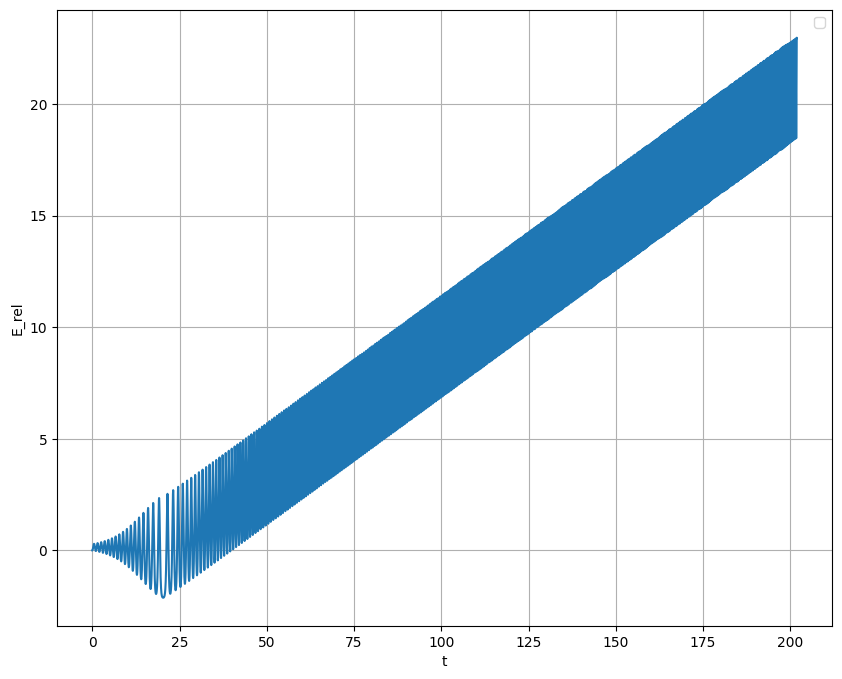

In [6]:
fig, ax = plt.subplots(figsize=(10,8))
ax.set_xlabel('t')
ax.set_ylabel('E_rel')
ax.plot(t, E_rel)
ax.legend()
ax.grid()

/tmp/ipykernel_1562/1026664881.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


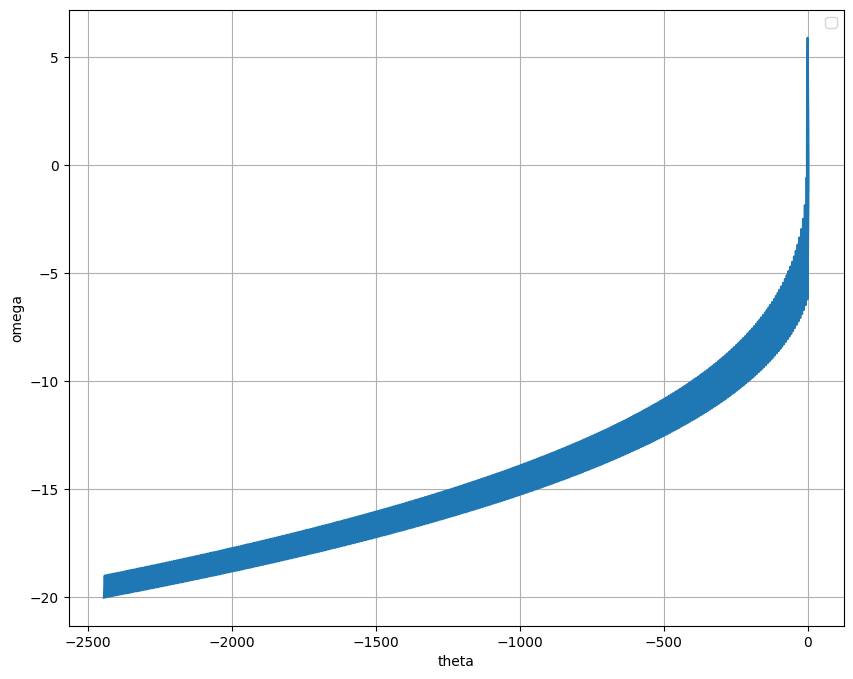

In [7]:
fig, ax = plt.subplots(figsize=(10,8))
ax.set_xlabel('theta')
ax.set_ylabel('omega')
ax.plot(y[:, 0], y[:, 1])
ax.legend()
ax.grid()

## Explicit midpoint method

In [8]:
t, y = integ.integrate(df_dt, t_range, IC, h, args=None, method=m.explicit_midpoint)

# IMPORTANTE: aggiungere .T a y per passare la trasposta (shape 2, N invece di N, 2)
E = compute_energy(y.T, args=[None]) 

# H_0 scala corretto (puoi usare anche direttamente E[0])
H_0 = compute_energy(IC, args=[None])

E_rel = (E - H_0)/H_0

/tmp/ipykernel_1562/1371019955.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


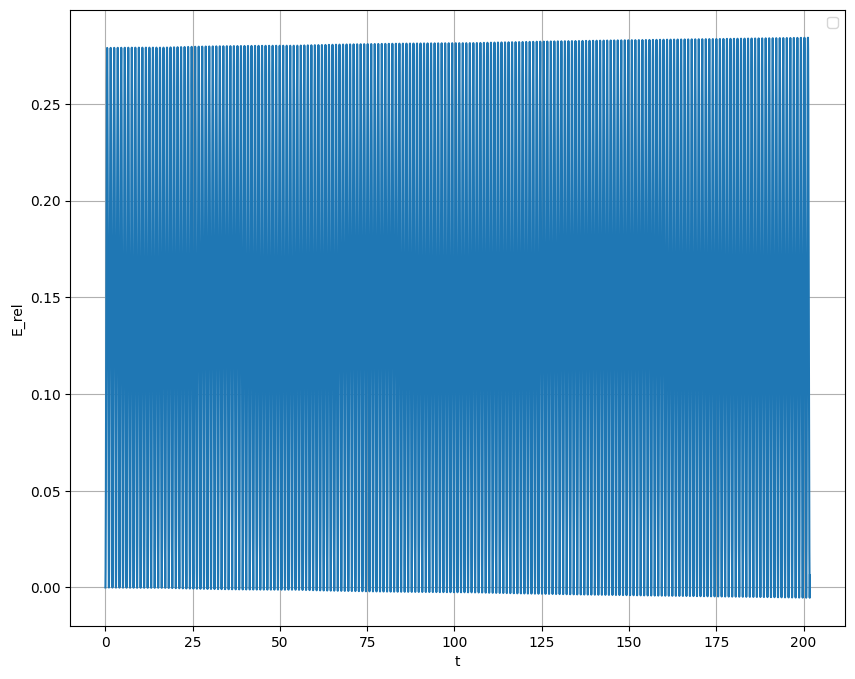

In [9]:
fig, ax = plt.subplots(figsize=(10,8))
ax.set_xlabel('t')
ax.set_ylabel('E_rel')
ax.plot(t, E_rel)
ax.legend()
ax.grid()

/tmp/ipykernel_1562/1026664881.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


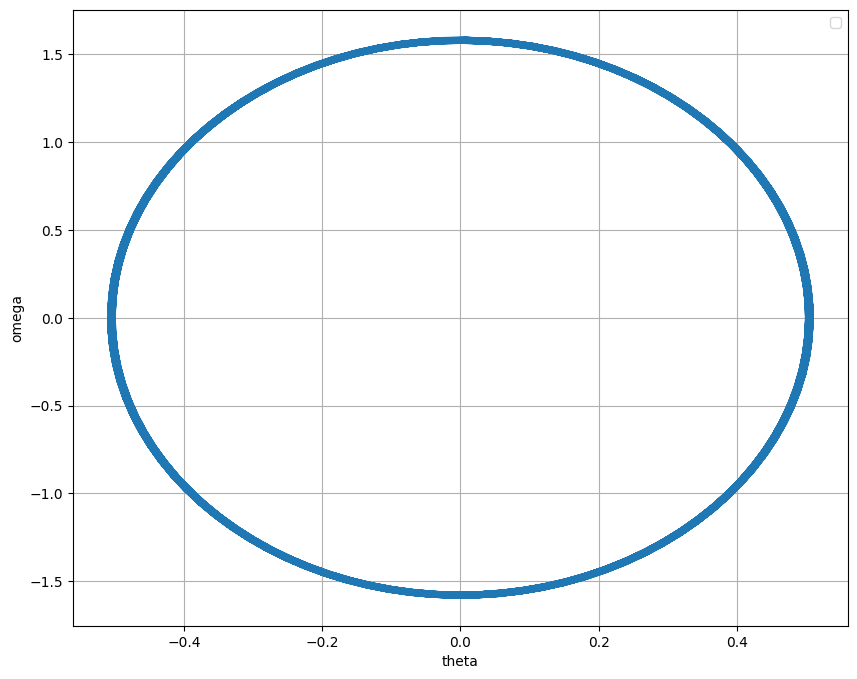

In [10]:
fig, ax = plt.subplots(figsize=(10,8))
ax.set_xlabel('theta')
ax.set_ylabel('omega')
ax.plot(y[:, 0], y[:, 1])
ax.legend()
ax.grid()

## RK4

In [11]:
t, y = integ.integrate(df_dt, t_range, IC, h, args=None, method=m.RK4)

# IMPORTANTE: aggiungere .T a y per passare la trasposta (shape 2, N invece di N, 2)
E = compute_energy(y.T, args=[None]) 

# H_0 scala corretto (puoi usare anche direttamente E[0])
H_0 = compute_energy(IC, args=[None])

E_rel = (E - H_0)/H_0

/tmp/ipykernel_1562/1371019955.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


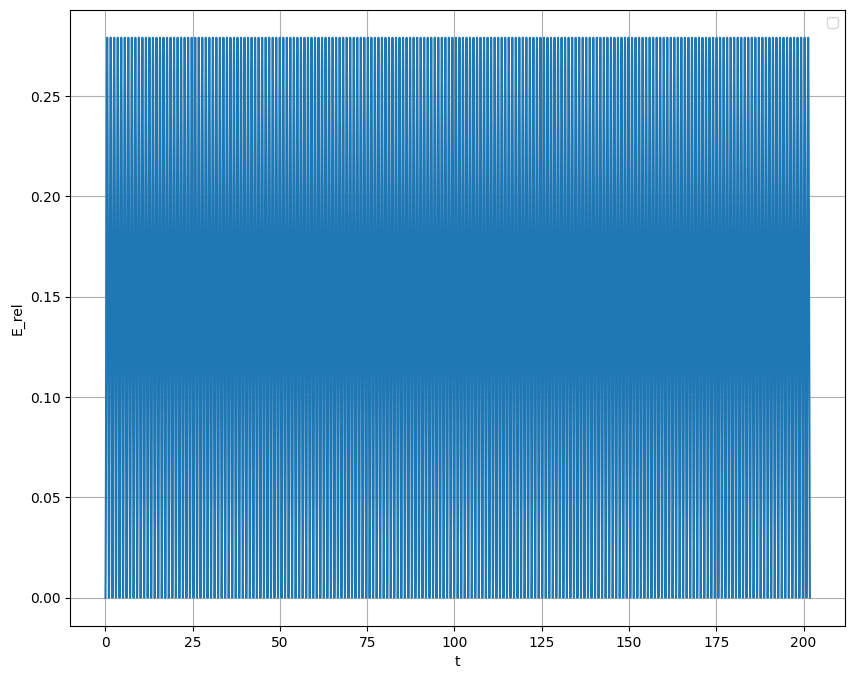

In [12]:
fig, ax = plt.subplots(figsize=(10,8))
ax.set_xlabel('t')
ax.set_ylabel('E_rel')
ax.plot(t, E_rel)
ax.legend()
ax.grid()

/tmp/ipykernel_1562/1026664881.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


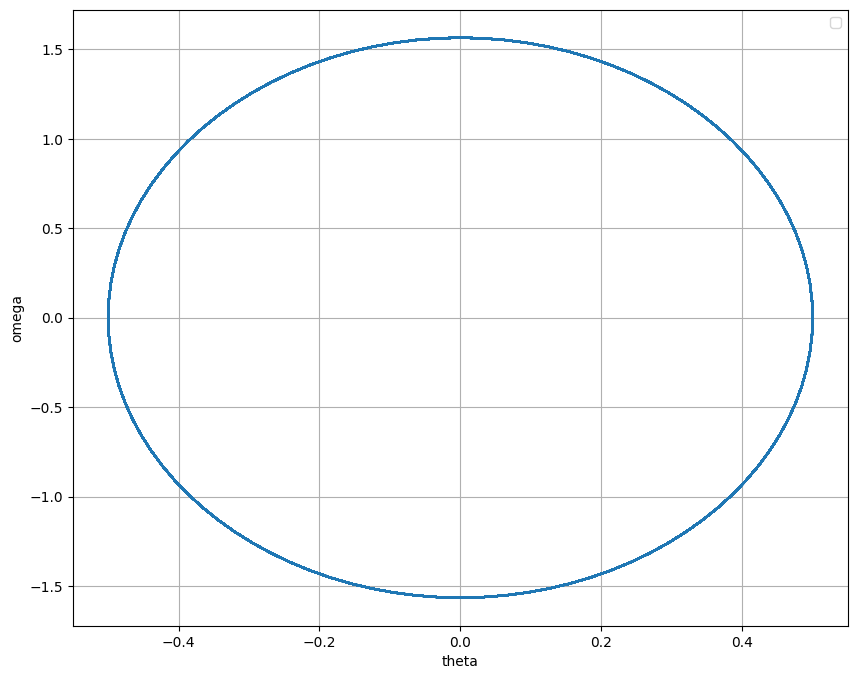

In [13]:
fig, ax = plt.subplots(figsize=(10,8))
ax.set_xlabel('theta')
ax.set_ylabel('omega')
ax.plot(y[:, 0], y[:, 1])
ax.legend()
ax.grid()

## leap frog kdk

In [18]:
t, y = integ.integrate(df_dt, t_range, IC, h, args=[None], method=m.leapfrog_KDK)

# IMPORTANTE: aggiungere .T a y per passare la trasposta (shape 2, N invece di N, 2)
E = compute_energy(y.T, args=[None]) 

# H_0 scala corretto (puoi usare anche direttamente E[0])
H_0 = compute_energy(IC, args=[None])

E_rel = (E - H_0)/H_0

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

/tmp/ipykernel_1562/1371019955.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


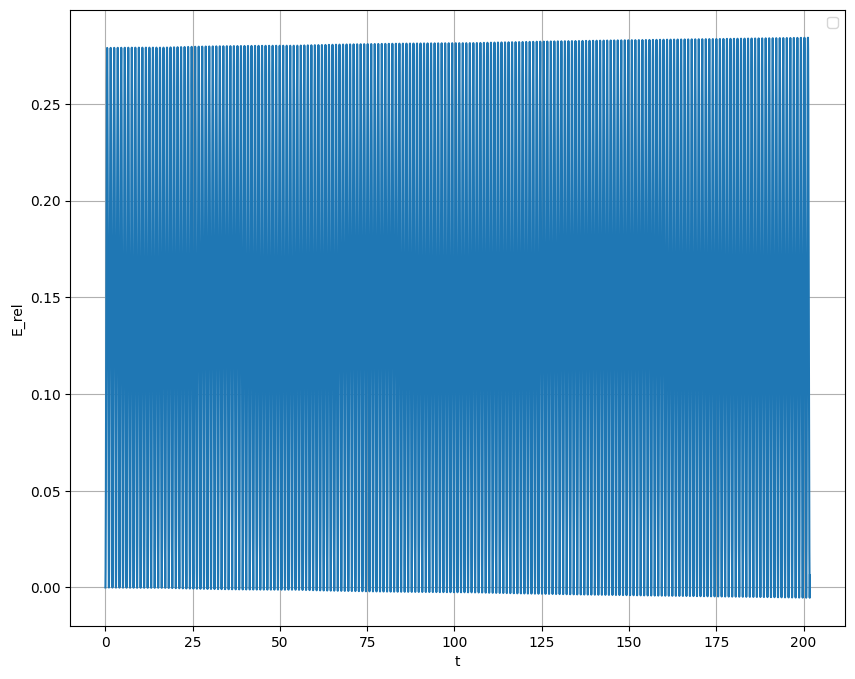

In [15]:
fig, ax = plt.subplots(figsize=(10,8))
ax.set_xlabel('t')
ax.set_ylabel('E_rel')
ax.plot(t, E_rel)
ax.legend()
ax.grid()

/tmp/ipykernel_1562/1026664881.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


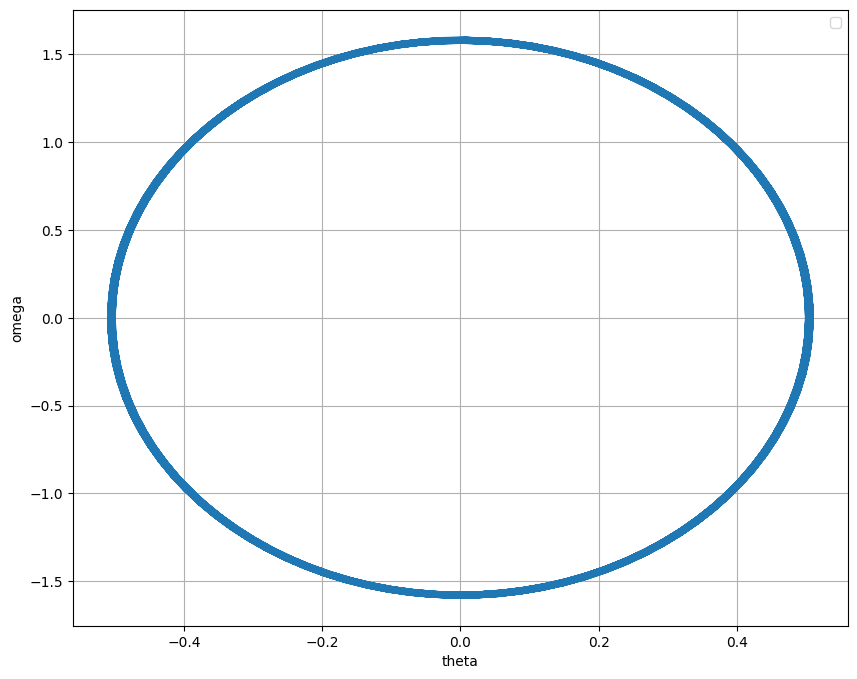

In [16]:
fig, ax = plt.subplots(figsize=(10,8))
ax.set_xlabel('theta')
ax.set_ylabel('omega')
ax.plot(y[:, 0], y[:, 1])
ax.legend()
ax.grid()

devo fare vari commenti,e magari anche conforntare i metodi, usarli meglio, e dare spiegazioni.

rivedo un po' se è tutto ok e poi faccio gli ultimi due metodi.

guardo anche come vanno le orbite nel phase space.

## Punto 4

Convergence study. For each method, integrate over 10 periods with h = T /N for
N = 50, 100, 200, 400, 800. Measure the global error at t = 10T (compare θ with the exact
solution obtained from the elliptic-function representation or a very high-accuracy reference
integration). Plot log(error) vs. log(h) and verify the expected convergence rates (slopes
1, 2, 4 for the respective methods).